In [36]:
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
df=pd.read_csv("../data/raw/student.csv")
print("Data successfully imported")

Data successfully imported


In [32]:
#df.head()
#df.describe()
#df.dtypes
df["b_date"]=pd.to_datetime(df["b_date"])
df["b_date"].dtypes
df.dtypes

name                  object
age                    int64
department            object
gpa                  float64
b_date        datetime64[ns]
dtype: object

In [33]:
df["name"].unique()
df["name"].value_counts()

name
Biniyam    1
Abebe      1
Abeba      1
Daniel     1
Name: count, dtype: int64

## Inconsistent Data

In [34]:
df["name"]=df["name"].str.lower()
#df["name"].unique()
df["name"]=df["name"].replace(
    {
        "biniyam" : "BINIYAM",
        "bini" : "Biniyam"
    }
)
df.head()

,name,age,department,gpa,b_date
0,BINIYAM,21,IS,3.8,2004-03-12
1,abebe,20,CS,3.9,2006-04-23
2,abeba,23,softwere,3.8,2005-05-19
3,daniel,2,Stat,3.6,2004-01-24


## Outliers

are unusually far away from most other values in the dataset. But, An outlier is NOT always invalid.

# Types of Outliers
 1. Global Outliers
    - Clearly far from all other values.
    - Example - 1, 2, 3, 4, 1000
 2. Contextual Outliers
    Outlier depending on context. 
    Example: - Temperature: 15°C normal in Addis Ababa unusual in Dubai summer

# Detecting Outliers
 1. Visual Detection - using Matplotlib
    - Very common in EDA. 2 mechanisms here:
      1.1 Boxplots are Excellent for outlier detection. Uses IQR method also.
      1.2 Histograms Help reveal skewed distributions.

 2. Statistical Detection — IQR Method

     'Formula' - IQR=Q3-Q1

    after finding the value of the IQR, there are rules on either to classify something as an outlier or not. 
    if x < Q1 - 1.5(IQR)  or X > Q3 + 1.5(IQR), then we can consider a feature has an outlier

 3. Z-Score method - Measures how many standard deviations a value is from the mean.

    'Formula' - Z = x - μ​ / std 
    |z| > 3 is most of the time an outlier
    - works best when data is approximately normally distributed.

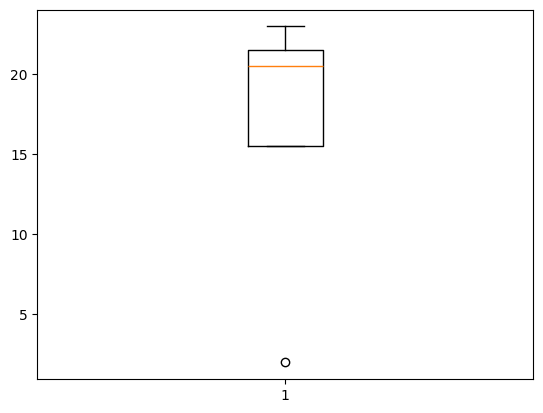

In [37]:
plt.boxplot(df["age"])
plt.show()

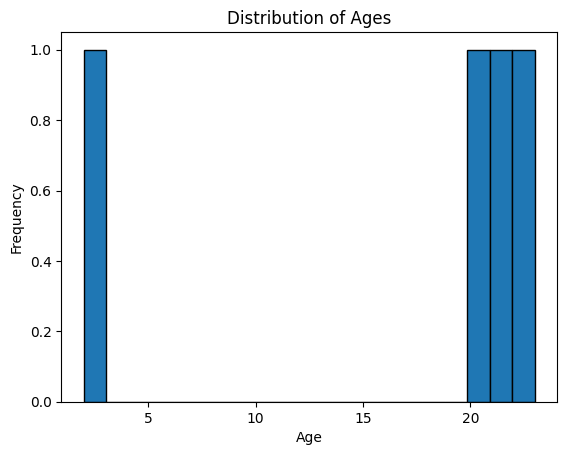

In [41]:
# Plot histogram of age
plt.hist(df["age"], bins=20, edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Ages")
plt.show()

In [39]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df["age"] < Q1 - 1.5 * IQR) |
    (df["age"] > Q3 + 1.5 * IQR)
]
outliers

,name,age,department,gpa,b_date
3,daniel,2,Stat,3.6,2004-01-24
